# CheMeleon + Mother CatBoost

**Goal:** Use a pretrained molecular foundation model (CheMeleon) to create molecular fingerprints, then use Mother's `CatboostRegressorMother` for FreeSolv property prediction.

This example keeps the downstream model simple: CheMeleon supplies the molecular representation and Mother's CatBoost wrapper performs the regression using the same estimator API used throughout the Mother examples.

## 1 - Set Up and Import Libraries

The setup cell requires `uv` and installs this checkout's `chemprop` extra into the active notebook kernel. Run this notebook with its own directory as the working directory, as required by the relative dataset path below.

If installation updates packages already imported in this kernel, restart the kernel before continuing with the imports.

In [6]:
import subprocess
import sys

subprocess.check_call(["uv", "pip", "install", "--python", sys.executable, "-e", "../../../[chemprop]"])

Using Python 3.12.14 environment at: /home/sagemaker-user/MotherML/.venv
Resolved 106 packages in 47ms
   Building mother-ml @ file:///home/sagemaker-user/MotherML
      Built mother-ml @ file:///home/sagemaker-user/MotherML
Prepared 1 package in 120ms
Uninstalled 1 package in 0.46ms
Installed 1 package in 5ms
 ~ mother-ml==1.2.0 (from file:///home/sagemaker-user/MotherML)


0

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split

from mother.feature_generation import CheMeleonFingerprintFactory
from mother.ml import CatboostRegressorMother

## 2 — Create CheMeleon Fingerprint Factory

`CheMeleonFingerprintFactory` requires Mother's `chemprop` extra, installed by the setup cell above.

For terminal-based setup, run `uv sync --extra chemprop` from the repository root and select that repository's `.venv` as the notebook kernel.

If no `checkpoint_path` is passed, Mother automatically downloads and caches the official CheMeleon foundation weights on first use. The CPU-friendly batch size below keeps memory use modest.

In [24]:
factory = CheMeleonFingerprintFactory(
    output_dim=2048,
    batch_size=128,  # lower memory footprint on CPU
    device="cpu",
)
fingerprinter = factory.get_fingerprint_generator()

print(f"✓ CheMeleon fingerprint generator ready  (output dim: {factory.output_dim})")
print("✓ Using automatic CheMeleon checkpoint provisioning (download + cache on first run)")

✓ CheMeleon fingerprint generator ready  (output dim: 2048)
✓ Using automatic CheMeleon checkpoint provisioning (download + cache on first run)


## 3 - Load the FreeSolv Dataset

[FreeSolv](https://github.com/MobleyLab/FreeSolv) contains experimental hydration free energies in kcal/mol. This notebook uses the 50-molecule training subset shipped with Mother's examples.

The 40/10 random split below demonstrates the API, not a reliable performance benchmark. For scientific evaluation, use an appropriate held-out dataset or repeated chemical-similarity/scaffold-aware splits, keep tuning within training folds, and check the pretrained model's data provenance for relevant overlap.

In [25]:
df = pd.read_csv("../freesolv_train.csv")
smiles = df["smiles"].tolist()
mols = [Chem.MolFromSmiles(s) for s in smiles]
targets = df["expt"].values.astype(np.float32)

print(f"Dataset: {len(df)} molecules")
df[["iupac", "smiles", "expt"]].head(10)

Dataset: 50 molecules


,iupac,smiles,expt
0,"4-methoxy-N,N-dimethyl-benzamide",CN(C)C(=O)c1ccc(cc1)OC,-11.01
1,methanesulfonyl chloride,CS(=O)(=O)Cl,-4.87
2,3-methylbut-1-ene,CC(C)C=C,1.83
3,2-ethylpyrazine,CCc1cnccn1,-5.45
4,heptan-1-ol,CCCCCCCO,-4.21
5,"3,5-dimethylphenol",Cc1cc(cc(c1)O)C,-6.27
6,"2,3-dimethylbutane",CC(C)C(C)C,2.34
7,2-methylpentan-2-ol,CCCC(C)(C)O,-3.92
8,"1,2-dimethylcyclohexane",C[C@@H]1CCCC[C@@H]1C,1.58
9,butan-2-ol,CC[C@H](C)O,-4.62


## 4 - Extract CheMeleon Fingerprints

`fit_transform` loads the frozen pretrained encoder and produces one 2048-dimensional vector per molecule. No FreeSolv target labels or dataset-fitted scaling are used here, so extracting these fixed representations before the split does not fit preprocessing to the test set.

If you add learned scaling, feature selection, or encoder fine-tuning, fit those steps only within training folds. Invalid molecules produce NaN rows and require explicit handling downstream.

In [26]:
mols_array = np.array(mols, dtype=object)
fingerprints = pd.DataFrame(
    fingerprinter.fit_transform(mols_array),
    columns=fingerprinter.get_feature_names_out(),
)
print(f"✓ Fingerprint matrix shape: {fingerprints.shape}")

✓ Fingerprint matrix shape: (50, 2048)


## 5 — Train / Test Split


In [27]:
X_train, X_test, y_train, y_test = train_test_split(fingerprints, targets, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} molecules, Test: {X_test.shape[0]} molecules")
print(f"Feature dim: {X_train.shape[1]}")

Train: 40 molecules, Test: 10 molecules
Feature dim: 2048


## 6 — Train and Evaluate Mother's CatBoost Regressor

`CatboostRegressorMother` is Mother's sklearn-compatible CatBoost wrapper. It keeps CatBoost's regression behavior while providing Mother's shared estimator conventions, hyperparameter-tuning hooks, and uncertainty interface.

Use Mother's `max_depth` parameter name, not CatBoost's `depth` alias. Mother already supplies a `max_depth` default, so passing `depth` would initialize both aliases and cause a CatBoost error.

The fingerprint DataFrame uses the `CheMeleonGNNFP_*` column names returned by `fingerprinter.get_feature_names_out()`. CatBoost retains those names for the feature-importance plot.

In [28]:
mother_catboost_model = CatboostRegressorMother(
    iterations=500,
    max_depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
)
mother_catboost_model.fit(X_train, y_train)

y_pred = mother_catboost_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mother CatBoost — RMSE: {rmse:.3f} kcal/mol, R²: {r2:.3f}")

Mother CatBoost — RMSE: 1.976 kcal/mol, R²: 0.548


## 7 - Visualise Predictions and Feature Importance

The parity plot illustrates the predictions on this small held-out subset. The wrapper exposes CatBoost feature importance for the numeric fingerprint coordinates.

CheMeleon dimensions are learned latent coordinates, not named chemical substructures. Their importance reflects this fitted model and representation; it is not a causal chemical explanation or evidence of performance beyond this split.

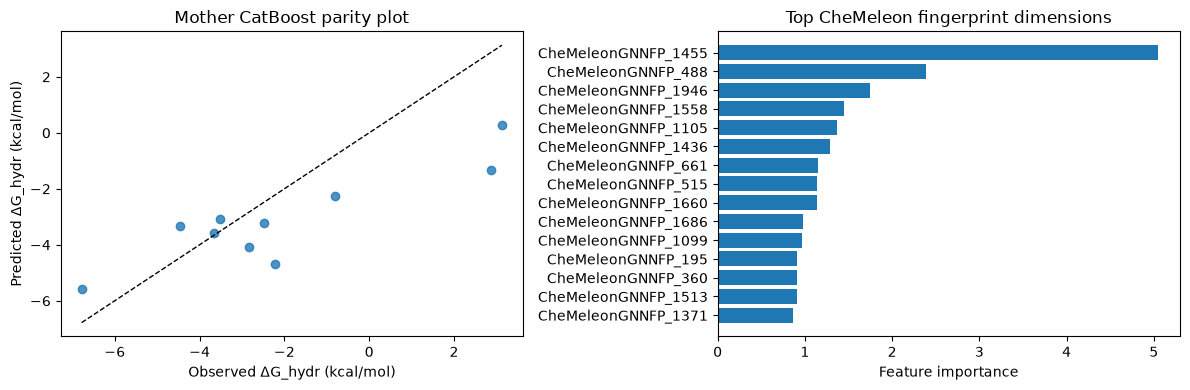

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_test, y_pred, alpha=0.8)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "k--", linewidth=1)
axes[0].set_xlabel("Observed ΔG_hydr (kcal/mol)")
axes[0].set_ylabel("Predicted ΔG_hydr (kcal/mol)")
axes[0].set_title("Mother CatBoost parity plot")

importance = mother_catboost_model.get_feature_importance()
top_indices = np.argsort(importance)[-15:]
axes[1].barh(np.arange(len(top_indices)), importance[top_indices])
axes[1].set_yticks(np.arange(len(top_indices)))
axes[1].set_yticklabels([mother_catboost_model.feature_names_[index] for index in top_indices])
axes[1].set_xlabel("Feature importance")
axes[1].set_title("Top CheMeleon fingerprint dimensions")

plt.tight_layout()
plt.show()

## 8 - Combine MACCS Fingerprints with CheMeleon Embeddings

Mother's official `MaccsFingerprints` transformer converts the RDKit molecules parsed from SMILES above into 167 numeric `maccs_*` columns.

The same DataFrame stores each molecule's complete CheMeleon vector in one `chemeleon_embedding` column. Each entry is a list of 2048 numeric values, not a scalar or string.

`CatboostRegressorMother` exposes CatBoost's dedicated `embedding_features` parameter. Setting `embedding_features=["chemeleon_embedding"]` activates CatBoost's embedding-specific feature processing alongside the ordinary MACCS numeric columns. Expanding the vector into separate numeric columns would not activate that functionality.

CatBoost derives features from the supplied vectors; it does not fine-tune the CheMeleon encoder. Both representations must describe the same molecule in each row, and `fit` and `predict` must receive the same column layout. The example reuses the existing split indices to keep features and targets aligned.

The resulting `embedding_predictions` are available for evaluation with datasets, validation splits, and metrics appropriate to your use case. This section demonstrates the integration, not a comparison of representations.

In [29]:
from mother.feature_generation import MaccsFingerprints

maccs_transformer = MaccsFingerprints()
X_maccs_embedding = pd.DataFrame(
    maccs_transformer.fit_transform(mols_array),
    columns=maccs_transformer.get_feature_names_out(),
    index=fingerprints.index,
)
X_maccs_embedding["chemeleon_embedding"] = fingerprints.to_numpy().tolist()

X_maccs_embedding_train = X_maccs_embedding.loc[X_train.index]
X_maccs_embedding_test = X_maccs_embedding.loc[X_test.index]

mother_catboost_embedding_model = CatboostRegressorMother(
    iterations=500,
    max_depth=6,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    embedding_features=["chemeleon_embedding"],
)
mother_catboost_embedding_model.fit(X_maccs_embedding_train, y_train)
embedding_predictions = mother_catboost_embedding_model.predict(X_maccs_embedding_test)